<a href="https://www.kaggle.com/code/nicapotato/ericsson-patent-analysis?scriptVersionId=340389660" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Guided Numeric Exploration — Ericsson Patent Evolution
_Half a century of telecom patents: volume, eras, and title-keyword trends_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [adamvakar/ericsson-innovation-timeline-patent-evolution](https://www.kaggle.com/datasets/adamvakar/ericsson-innovation-timeline-patent-evolution)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Data Dictionary — Keyword Flags](#Dictionary)** <br>
**4. [Patent-Level Univariate](#Univariate)** <br>
**5. [Quarterly Filing Volume](#Quarter)** <br>
**6. [Keyword and Era Trends](#Keywords)** <br>
**7. [Title Wordclouds](#Wordclouds)** <br>
**8. [Smartphone 2010s Breakdown](#Smartphone)** <br>
**9. [Forecasting Grain Caution](#Forecast)** <br>
**10. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
Ericsson patent filings from **1976–2025** (30,118 patents, 199 quarters) with engineered title keywords, tech eras, and quarter-level lags/targets duplicated onto every patent row.

**Grain matter:** `patent_count`, lags, YoY/QoQ, and `target_patent_count_*` are **quarter aggregates** repeated on each patent. Time-series plots and forecasting must use a deduped quarter table. Predicting next-quarter count with current `patent_count` / `target_patent_count_current` is leakage.

License note: CC-BY-NC-SA-4.0 — non-commercial share-alike constraints apply if you republish derivatives.



# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from collections import Counter
import re
from wordcloud import STOPWORDS, WordCloud
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)



**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `wordcloud` / `Counter` / `re` support title-token clouds later; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "ericsson_patent_rich_dataset.csv"
KAGGLE_SLUG = "adamvakar/ericsson-innovation-timeline-patent-evolution"
KW_FLAGS = [
    "kw_5g", "kw_ai_ml", "kw_cloud_edge", "kw_security", "kw_iot",
    "kw_network", "kw_energy", "kw_antenna", "kw_data",
]
CORE_COLS = [
    "patent_id", "patent_type", "patent_date", "patent_title", "year", "quarter",
    "tech_era", "patent_count", "target_patent_count_current", "target_patent_count_next_quarter",
    "title_len_words", "keyword_score",
] + KW_FLAGS


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        hits = list(kaggle_root.rglob(CSV_BASENAME))
        assert hits, f"{CSV_BASENAME} not under /kaggle/input"
        return hits[0]
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    hits = list(root.rglob(CSV_BASENAME))
    assert hits, f"expected {CSV_BASENAME} under {root}"
    return hits[0]


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path, low_memory=False)
missing = set(CORE_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 30118, f"expected 30118 rows, got {len(df)}"
assert df["patent_id"].is_unique

df["patent_date"] = pd.to_datetime(df["patent_date"], errors="coerce")
assert df["patent_date"].notna().all()

quarter_df = (
    df.drop_duplicates(["year", "quarter"])
    .sort_values(["year", "quarter"])
    .reset_index(drop=True)
)
assert len(quarter_df) == 199, f"expected 199 quarters, got {len(quarter_df)}"
assert quarter_df.groupby(["year", "quarter"])["patent_count"].nunique().max() == 1

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in CORE_COLS]
print("Missing Values (core):", df[CORE_COLS].isnull().sum().sum())
print("Patent rows:", len(df), "| Quarters:", len(quarter_df))
print("Year range:", int(df["year"].min()), int(df["year"].max()))
print("patent_type:", df["patent_type"].value_counts().to_dict())
print("tech_era:", df["tech_era"].value_counts().to_dict())
print("Next-quarter target null share: {:.2%}".format(df["target_patent_count_next_quarter"].isna().mean()))


CSV: /kaggle/input/datasets/adamvakar/ericsson-innovation-timeline-patent-evolution/ericsson_patent_rich_dataset.csv
Missing Values (core): 408
Patent rows: 30118 | Quarters: 199
Year range: 1976 2025
patent_type: {'utility': 29694, 'design': 376, 'reissue': 48}
tech_era: {'smartphone_2010s': 13841, 'modern_2020s': 8147, 'mobile_2000s': 5740, 'legacy_1990s': 1954, 'legacy_pre_1990': 436}
Next-quarter target null share: 1.35%


**Code Explanation and Reasoning:** <br>
Patent IDs are unique. Quarter grain is built by dropping duplicate `(year, quarter)` rows and asserting 199 quarters with a constant `patent_count` within each quarter. Next-quarter target nulls are expected on the final quarter(s).


In [3]:
df[CORE_COLS].sample(5, random_state=7)


,patent_id,patent_type,patent_date,patent_title,year,quarter,tech_era,patent_count,target_patent_count_current,target_patent_count_next_quarter,title_len_words,keyword_score,kw_5g,kw_ai_ml,kw_cloud_edge,kw_security,kw_iot,kw_network,kw_energy,kw_antenna,kw_data
4818,6507820,utility,2003-01-14,Speech band sampling rate expansion,2003,1,mobile_2000s,159,159,187.0,5,0,0,0,0,0,0,0,0,0,0
18430,9749838,utility,2017-08-29,PMIP protocol enhancement,2017,3,smartphone_2010s,423,423,371.0,3,0,0,0,0,0,0,0,0,0,0
28933,12185289,utility,2024-12-31,Adapting operations in flexible allocation slo...,2024,4,modern_2020s,410,410,399.0,11,0,0,0,0,0,0,0,0,0,0
23140,10820286,utility,2020-10-27,Narrowband LTE cell search,2020,4,modern_2020s,315,315,385.0,4,0,0,0,0,0,0,0,0,0,0
11365,8412124,utility,2013-04-02,Multi-band peak power reduction,2013,2,smartphone_2010s,302,302,347.0,4,1,0,0,0,0,0,0,1,0,0


In [4]:
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]))
df[["title_len_words", "keyword_score"] + KW_FLAGS].describe().T.round(3)


,Column,Unique,Null
0,patent_id,30118,0
1,patent_type,3,0
2,patent_date,2069,0
3,patent_title,25421,0
4,year,50,0
5,quarter,4,0
6,tech_era,5,0
7,patent_count,132,0
8,target_patent_count_current,132,0
9,target_patent_count_next_quarter,133,408


,count,mean,std,min,25%,50%,75%,max
title_len_words,30118.0,8.820,4.384,1.0,6.0,8.0,11.0,39.0
keyword_score,30118.0,0.595,0.647,0.0,0.0,1.0,1.0,4.0
kw_5g,30118.0,0.007,0.085,0.0,0.0,0.0,0.0,1.0
kw_ai_ml,30118.0,0.004,0.062,0.0,0.0,0.0,0.0,1.0
kw_cloud_edge,30118.0,0.016,0.125,0.0,0.0,0.0,0.0,1.0
kw_security,30118.0,0.011,0.104,0.0,0.0,0.0,0.0,1.0
kw_iot,30118.0,0.004,0.061,0.0,0.0,0.0,0.0,1.0
kw_network,30118.0,0.404,0.491,0.0,0.0,0.0,1.0,1.0
kw_energy,30118.0,0.046,0.210,0.0,0.0,0.0,0.0,1.0
kw_antenna,30118.0,0.041,0.198,0.0,0.0,0.0,0.0,1.0


**Interpretation** <br>
Utility patents dominate. Keyword flags are sparse except `kw_network`. Quarter aggregates on patent rows inflate any naive mean of `patent_count` — always use `quarter_df` for volume.


# **3. Data Dictionary — Keyword Flags:** <a id="Dictionary"></a>

The dataset author extracted **nine binary technology indicators from `patent_title` with domain-specific regex** (not from claims or CPC codes). Exact regex strings are not published; meanings below combine the dataset card with title cues that fire each flag in this file.

`keyword_score` is **not** a quality score — it is the count of how many `kw_*` flags equal 1 on that patent (observed range 0–4).


In [5]:
# Field meanings for the keyword block (and closely related columns)
kw_dictionary = pd.DataFrame([
    {
        "column": "kw_5g",
        "type": "binary 0/1",
        "meaning": "Title language associated with 5G / New Radio (NR).",
        "title_cues_seen": "5g, nr, new radio",
    },
    {
        "column": "kw_ai_ml",
        "type": "binary 0/1",
        "meaning": "Title language associated with AI / ML / learned models.",
        "title_cues_seen": "machine learning, neural, model/modeling (also older 'model' uses)",
    },
    {
        "column": "kw_cloud_edge",
        "type": "binary 0/1",
        "meaning": "Title language associated with cloud, edge, or virtualization.",
        "title_cues_seen": "cloud, edge, virtual / virtualized / container (false friends exist)",
    },
    {
        "column": "kw_security",
        "type": "binary 0/1",
        "meaning": "Title language associated with security / trust / crypto.",
        "title_cues_seen": "security, authentication, encryption, cipher, trusted",
    },
    {
        "column": "kw_iot",
        "type": "binary 0/1",
        "meaning": "Title language associated with IoT / sensing.",
        "title_cues_seen": "iot, internet of things, sensor(s) — includes non-IoT 'sensor' patents",
    },
    {
        "column": "kw_network",
        "type": "binary 0/1",
        "meaning": "Broad networking / radio / transmission title language (most common flag).",
        "title_cues_seen": "network(s), radio, transmission, arrangement, ...",
    },
    {
        "column": "kw_energy",
        "type": "binary 0/1",
        "meaning": "Power / energy / battery / efficiency title language.",
        "title_cues_seen": "power, battery, energy, consumption, efficiency",
    },
    {
        "column": "kw_antenna",
        "type": "binary 0/1",
        "meaning": "Antenna / MIMO / beamforming title language.",
        "title_cues_seen": "antenna(s), mimo, beamforming",
    },
    {
        "column": "kw_data",
        "type": "binary 0/1",
        "meaning": "Data / database / analytics title language.",
        "title_cues_seen": "data, database, analytics",
    },
    {
        "column": "keyword_score",
        "type": "integer count",
        "meaning": "Sum of the nine kw_* flags on the row (how many title themes co-occur).",
        "title_cues_seen": "equals sum(kw_*); max observed = 4",
    },
    {
        "column": "tech_era",
        "type": "categorical",
        "meaning": "Calendar decade bucket assigned from filing year (not inferred from title).",
        "title_cues_seen": "legacy_pre_1990(1976–89), legacy_1990s, mobile_2000s, smartphone_2010s, modern_2020s",
    },
    {
        "column": "kw_*_count",
        "type": "quarter aggregate",
        "meaning": "Count of patents with that kw_* = 1 in the same quarter (duplicated onto every patent in the quarter).",
        "title_cues_seen": "use only on quarter_df / after drop_duplicates(year, quarter)",
    },
])
display(kw_dictionary)

# Sanity: keyword_score must equal the sum of binary flags
assert (df["keyword_score"] == df[KW_FLAGS].sum(axis=1)).all()
print("keyword_score == sum(kw_*): OK")
print("kw_* prevalence:")
display(df[KW_FLAGS].mean().sort_values(ascending=False).rename("share").to_frame().round(4))



,column,type,meaning,title_cues_seen
0,kw_5g,binary 0/1,Title language associated with 5G / New Radio ...,"5g, nr, new radio"
1,kw_ai_ml,binary 0/1,Title language associated with AI / ML / learn...,"machine learning, neural, model/modeling (also..."
2,kw_cloud_edge,binary 0/1,"Title language associated with cloud, edge, or...","cloud, edge, virtual / virtualized / container..."
3,kw_security,binary 0/1,Title language associated with security / trus...,"security, authentication, encryption, cipher, ..."
4,kw_iot,binary 0/1,Title language associated with IoT / sensing.,"iot, internet of things, sensor(s) — includes ..."
5,kw_network,binary 0/1,Broad networking / radio / transmission title ...,"network(s), radio, transmission, arrangement, ..."
6,kw_energy,binary 0/1,Power / energy / battery / efficiency title la...,"power, battery, energy, consumption, efficiency"
7,kw_antenna,binary 0/1,Antenna / MIMO / beamforming title language.,"antenna(s), mimo, beamforming"
8,kw_data,binary 0/1,Data / database / analytics title language.,"data, database, analytics"
9,keyword_score,integer count,Sum of the nine kw_* flags on the row (how man...,equals sum(kw_*); max observed = 4


keyword_score == sum(kw_*): OK
kw_* prevalence:


,share
kw_network,0.4040
kw_data,0.0625
kw_energy,0.0463
kw_antenna,0.0408
kw_cloud_edge,0.0159
kw_security,0.0110
kw_5g,0.0072
kw_ai_ml,0.0039
kw_iot,0.0038


**How to Interpret:** <br>
Treat each `kw_*` as a **title keyword detector**, not a ground-truth technology taxonomy. `kw_network` is broad and frequent; modern tags (`kw_5g`, `kw_ai_ml`, `kw_iot`) are rare and late. False friends exist (e.g. `kw_iot` can fire on generic “sensor” titles; `kw_ai_ml` can fire on older “model” language). For volume of flagged patents over time, prefer `kw_*_count` on the deduped quarter table.


# **4. Patent-Level Univariate:** <a id="Univariate"></a>



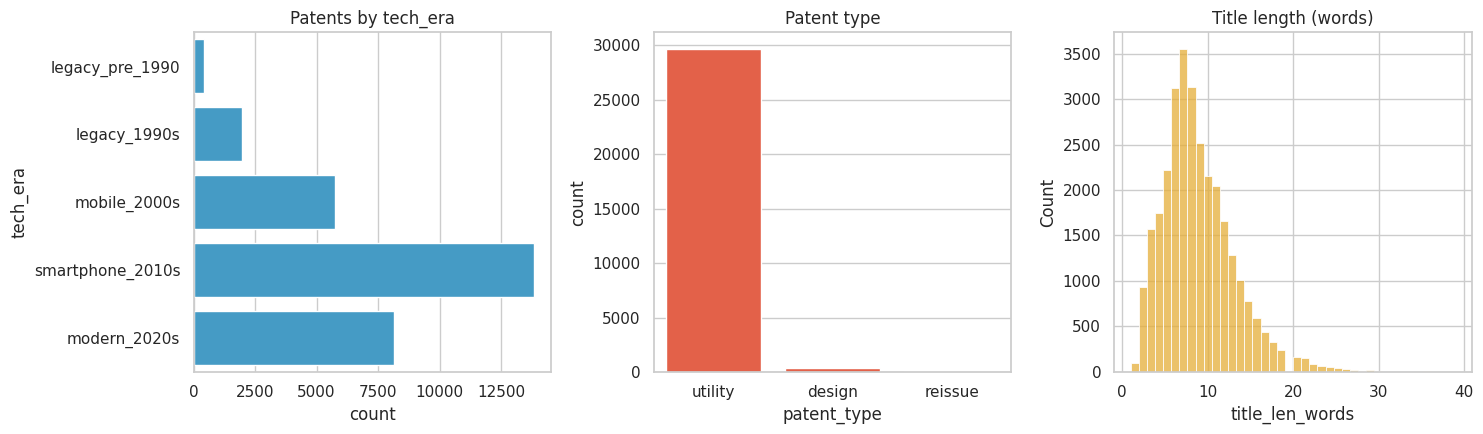

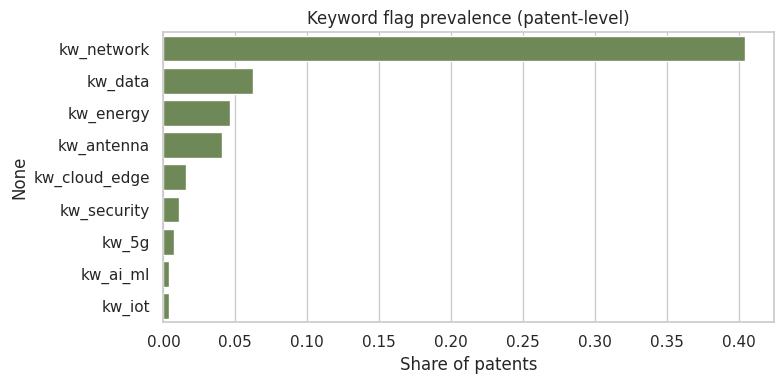

In [6]:
era_order = [
    "legacy_pre_1990", "legacy_1990s", "mobile_2000s", "smartphone_2010s", "modern_2020s",
]
era_order = [e for e in era_order if e in set(df["tech_era"])]
f, ax = plt.subplots(1, 3, figsize=(15, 4.5))
sns.countplot(data=df, y="tech_era", order=era_order, ax=ax[0], color="#30a2da")
ax[0].set_title("Patents by tech_era")
sns.countplot(data=df, x="patent_type", ax=ax[1], color="#fc4f30")
ax[1].set_title("Patent type")
sns.histplot(df["title_len_words"], bins=40, ax=ax[2], color="#e5ae38")
ax[2].set_title("Title length (words)")
plt.tight_layout()
plt.show()

kw_rate = df[KW_FLAGS].mean().sort_values(ascending=False)
f, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=kw_rate.values, y=kw_rate.index, ax=ax, color="#6d904f")
ax.set_title("Keyword flag prevalence (patent-level)")
ax.set_xlabel("Share of patents")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
Era counts reflect both filing intensity and how long each era label spans. Keyword bars show title vocabulary coverage — network is common; 5G/AI are rare absolute events.


# **5. Quarterly Filing Volume:** <a id="Quarter"></a>



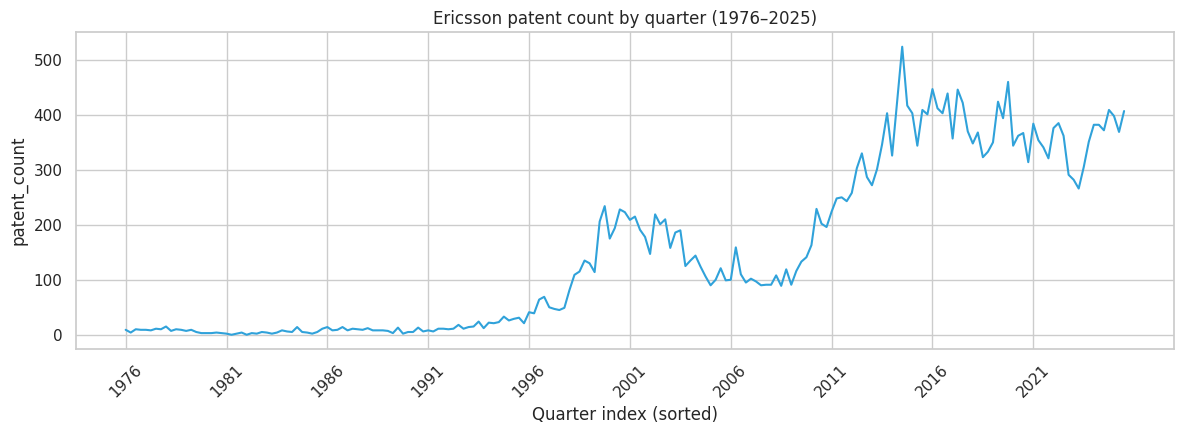

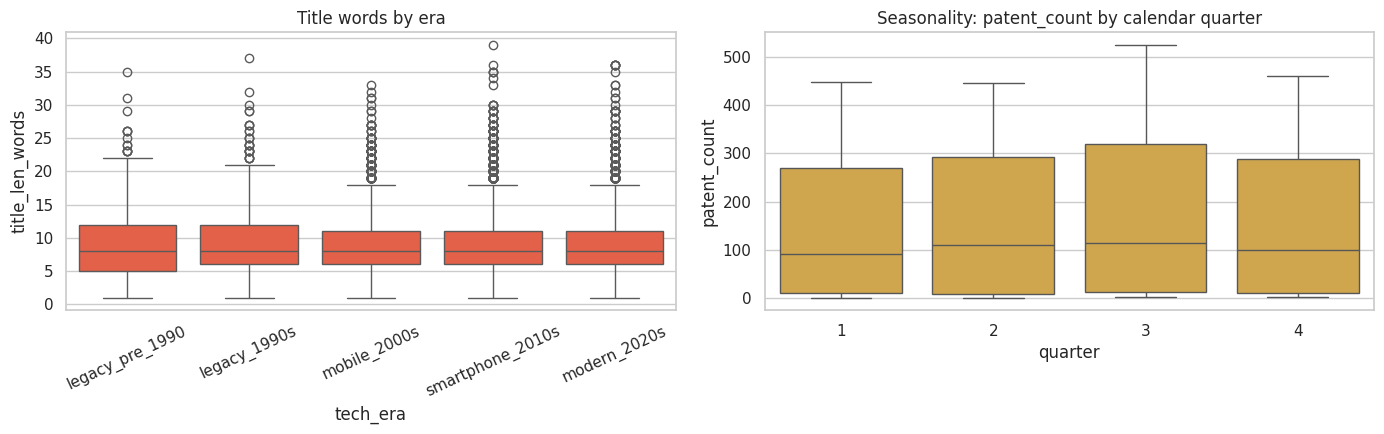

In [7]:
quarter_df = quarter_df.copy()
quarter_df["period"] = pd.PeriodIndex.from_fields(
    year=quarter_df["year"], quarter=quarter_df["quarter"]
).astype(str)

f, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(range(len(quarter_df)), quarter_df["patent_count"], color="#30a2da", lw=1.5)
ax.set_title("Ericsson patent count by quarter (1976–2025)")
ax.set_xlabel("Quarter index (sorted)")
ax.set_ylabel("patent_count")
# light year ticks
year_starts = quarter_df.reset_index().groupby("year")["index"].min()
tick_years = year_starts.index[::5]
ax.set_xticks([year_starts[y] for y in tick_years])
ax.set_xticklabels(tick_years, rotation=45)
plt.tight_layout()
plt.show()

f, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df, x="tech_era", y="title_len_words", order=era_order, ax=ax[0], color="#fc4f30")
ax[0].set_title("Title words by era")
ax[0].tick_params(axis="x", rotation=25)
sns.boxplot(data=quarter_df, x="quarter", y="patent_count", ax=ax[1], color="#e5ae38")
ax[1].set_title("Seasonality: patent_count by calendar quarter")
plt.tight_layout()
plt.show()


**How to Interpret:** <br>
The quarter series is the real innovation-volume clock. Calendar-quarter boxes ask whether Q1–Q4 filing seasonality exists beyond the long-run trend.


# **6. Keyword and Era Trends:** <a id="Keywords"></a>



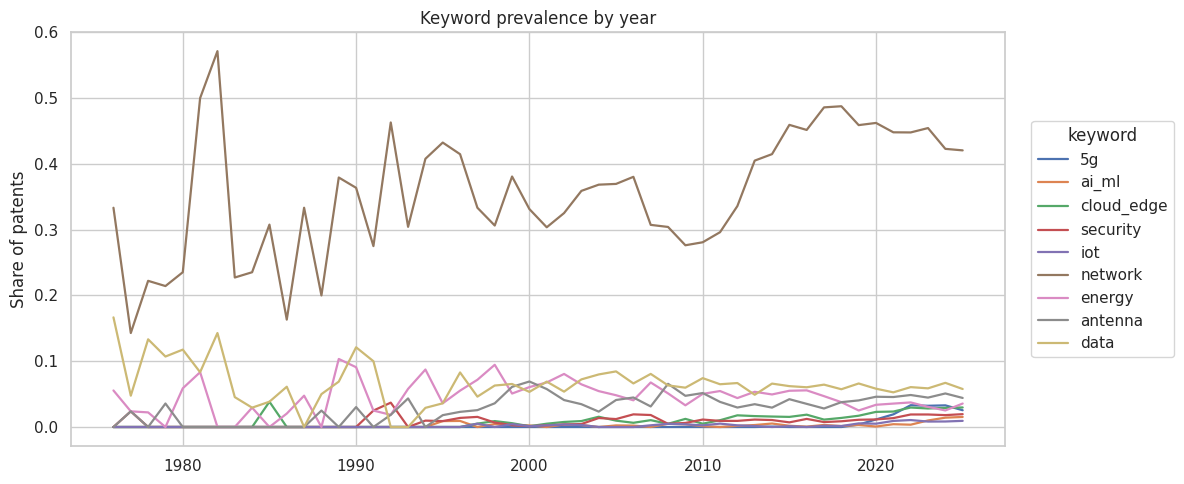

,kw_5g,kw_ai_ml,kw_cloud_edge,kw_security,kw_iot,kw_network,kw_energy,kw_antenna,kw_data
tech_era,,,,,,,,,
smartphone_2010s,0.001,0.002,0.015,0.010,0.002,0.421,0.047,0.036,0.063
modern_2020s,0.026,0.008,0.027,0.017,0.008,0.443,0.033,0.047,0.059


In [8]:
# Annual keyword shares (patent-level rates)
annual = df.groupby("year")[KW_FLAGS].mean()
f, ax = plt.subplots(figsize=(12, 5))
for col in KW_FLAGS:
    ax.plot(annual.index, annual[col], label=col.replace("kw_", ""), lw=1.6)
ax.set_title("Keyword prevalence by year")
ax.set_ylabel("Share of patents")
ax.legend(title="keyword", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

# Focus late eras for sparse modern keywords
modern = df[df["year"] >= 2010]
display(modern.groupby("tech_era")[KW_FLAGS].mean().reindex(
    [e for e in era_order if e in set(modern["tech_era"])]
).round(3))


**How to Interpret:** <br>
Rising 5G / AI / cloud lines in the 2010s–2020s mark title-language shifts. Because flags are title-string heuristics, absence of a keyword is not absence of the technology in the patent body.


# **7. Title Wordclouds:** <a id="Wordclouds"></a>

Binary `kw_*` flags only catch a fixed vocabulary. Wordclouds on raw `patent_title` tokens show what language actually dominates by **patent type** and by **decade**.


utility (n=29694): [('network', 5853.0), ('wireless', 2721.0), ('radio', 2544.0), ('control', 1956.0), ('data', 1872.0), ('mobile', 1819.0), ('node', 1746.0), ('access', 1576.0), ('transmission', 1357.0), ('power', 1212.0), ('user', 1162.0), ('channel', 1148.0)]
design (n=376): [('mobile', 125.0), ('phone', 88.0), ('telephone', 61.0), ('portable', 34.0), ('radio', 22.0), ('battery', 21.0), ('headset', 18.0), ('radiotelephone', 14.0), ('charger', 14.0), ('handsfree', 12.0), ('unit', 11.0), ('housing', 10.0)]
reissue (n=48): [('radio', 15.0), ('mobile', 10.0), ('user', 8.0), ('information', 7.0), ('equipment', 7.0), ('network', 6.0), ('cellular', 5.0), ('digital', 5.0), ('handover', 5.0), ('use', 4.0), ('biometric', 4.0), ('gui', 4.0)]


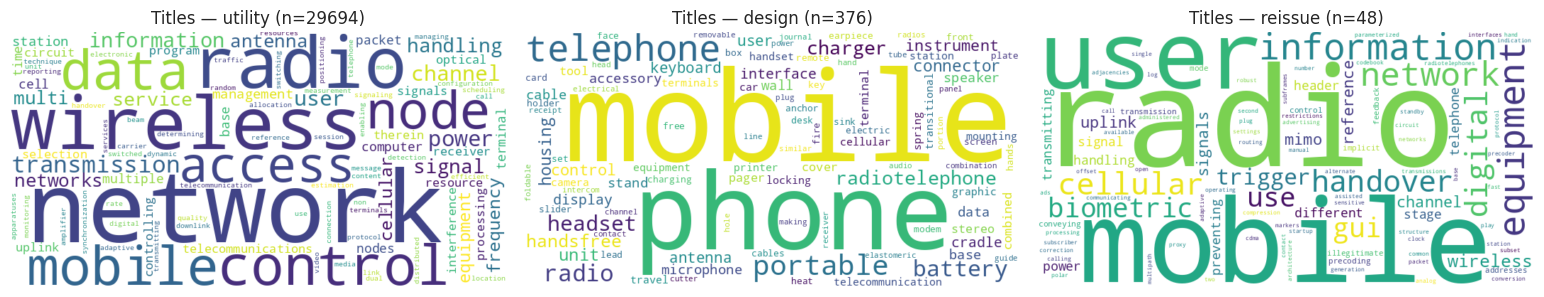

1970s (n=151): [('telephone', 21.0), ('data', 17.0), ('circuit', 14.0), ('two', 11.0), ('digital', 11.0), ('cable', 10.0), ('signal', 9.0), ('switching', 9.0), ('signals', 8.0), ('memory', 8.0)]
1980s (n=285): [('telephone', 33.0), ('digital', 21.0), ('optical', 21.0), ('signal', 18.0), ('data', 16.0), ('transmission', 16.0), ('circuit', 16.0), ('cable', 15.0), ('information', 14.0), ('telecommunication', 14.0)]
1990s (n=1954): [('radio', 270.0), ('mobile', 262.0), ('cellular', 212.0), ('network', 173.0), ('telephone', 151.0), ('channel', 130.0), ('data', 119.0), ('control', 118.0), ('telecommunications', 111.0), ('digital', 98.0)]
2000s (n=5740): [('mobile', 713.0), ('network', 651.0), ('radio', 458.0), ('data', 379.0), ('control', 348.0), ('wireless', 320.0), ('power', 289.0), ('telecommunications', 257.0), ('antenna', 238.0), ('signal', 229.0)]
2010s (n=13841): [('network', 2947.0), ('wireless', 1241.0), ('radio', 1079.0), ('control', 960.0), ('node', 917.0), ('data', 859.0), ('mobi

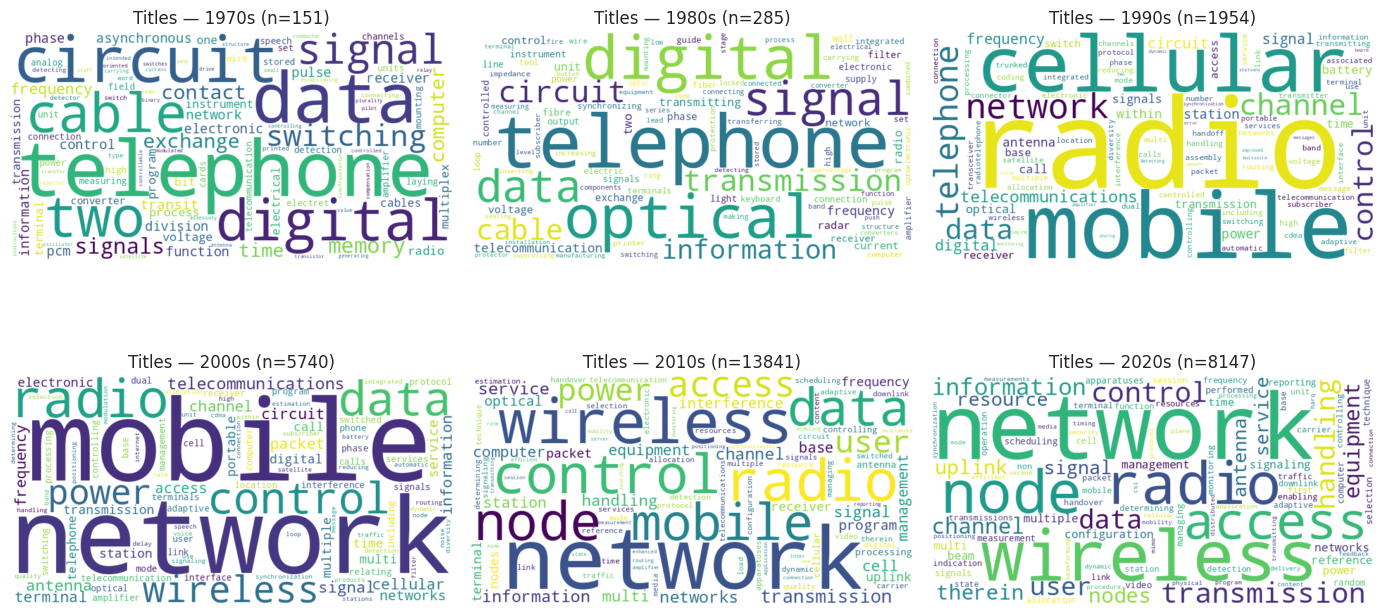

In [9]:
# Title token frequencies -> wordclouds by patent_type and by decade
PATENT_STOP = STOPWORDS | {
    "method", "methods", "apparatus", "system", "systems", "device", "devices",
    "using", "thereof", "based", "providing", "comprising", "related", "means",
    "arrangement", "arrangements", "communication", "communications",
}

df = df.copy()
df["decade"] = (df["year"] // 10) * 10


def titles_to_wordfreq(names: pd.Series) -> dict[str, float]:
    text = " ".join(names.astype(str).str.lower())
    tokens = re.findall(r"[a-z0-9]+", text)
    filtered = [t for t in tokens if t not in PATENT_STOP and len(t) > 2]
    counts = Counter(filtered)
    return {w: float(c) for w, c in counts.items()}


def show_wordcloud(freq: dict[str, float], title: str, ax=None) -> None:
    assert freq, f"no tokens for: {title}"
    wc = WordCloud(
        width=700,
        height=360,
        background_color="white",
        max_words=100,
        collocations=False,
        prefer_horizontal=0.9,
        colormap="viridis",
    ).generate_from_frequencies(freq)
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title)
    if own_fig:
        plt.tight_layout()
        plt.show()


# --- By patent type ---
type_order = df["patent_type"].value_counts().index.tolist()
n_type = len(type_order)
f, axes = plt.subplots(1, n_type, figsize=(5.2 * n_type, 4.2))
if n_type == 1:
    axes = [axes]
for ax, ptype in zip(axes, type_order):
    sub = df.loc[df["patent_type"] == ptype, "patent_title"]
    freq = titles_to_wordfreq(sub)
    top = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:12]
    print(f"{ptype} (n={len(sub)}):", top)
    show_wordcloud(freq, f"Titles — {ptype} (n={len(sub)})", ax=ax)
plt.tight_layout()
plt.show()

# --- By decade ---
decade_order = sorted(df["decade"].unique())
f, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, decade in zip(axes, decade_order):
    sub = df.loc[df["decade"] == decade, "patent_title"]
    freq = titles_to_wordfreq(sub)
    top = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"{decade}s (n={len(sub)}):", top)
    show_wordcloud(freq, f"Titles — {decade}s (n={len(sub)})", ax=ax)
for ax in axes[len(decade_order):]:
    ax.axis("off")
plt.tight_layout()
plt.show()



**How to Interpret:** <br>
Utility titles carry the technical vocabulary (`radio`, `network`, `node`, `wireless`, …). Design patents skew toward product/form language and are rare. Decade clouds move from hardware/exchange wording in early decades toward radio-access / wireless / node language in the 2010s, then 5G-adjacent phrasing in the 2020s — complementary to the sparse `kw_5g` / `kw_ai_ml` rates.


# **8. Smartphone 2010s Breakdown:** <a id="Smartphone"></a>

`tech_era == smartphone_2010s` is simply **filing years 2010–2019** (13,841 patents) — the densest era in the table. Below: year-by-year volume, keyword prevalence inside the era, early vs late half, and a title wordcloud.


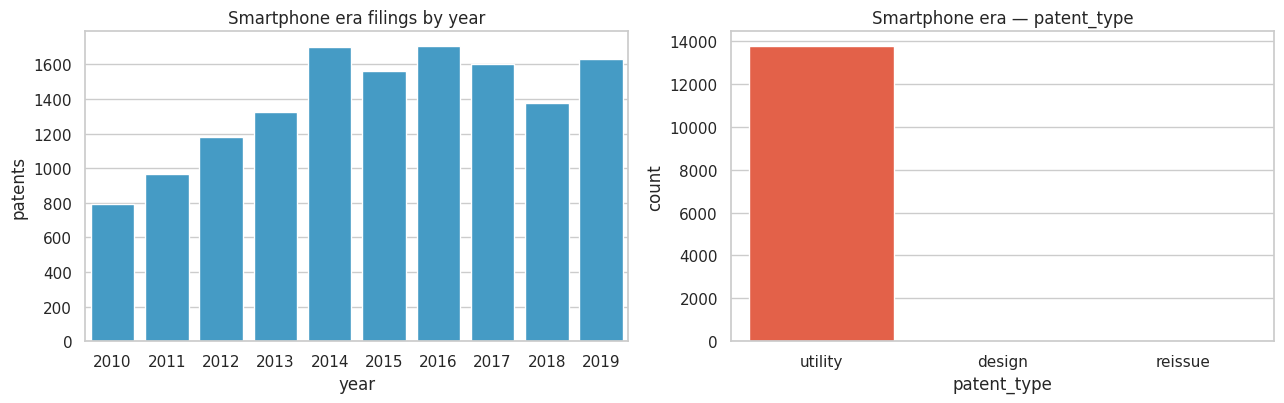

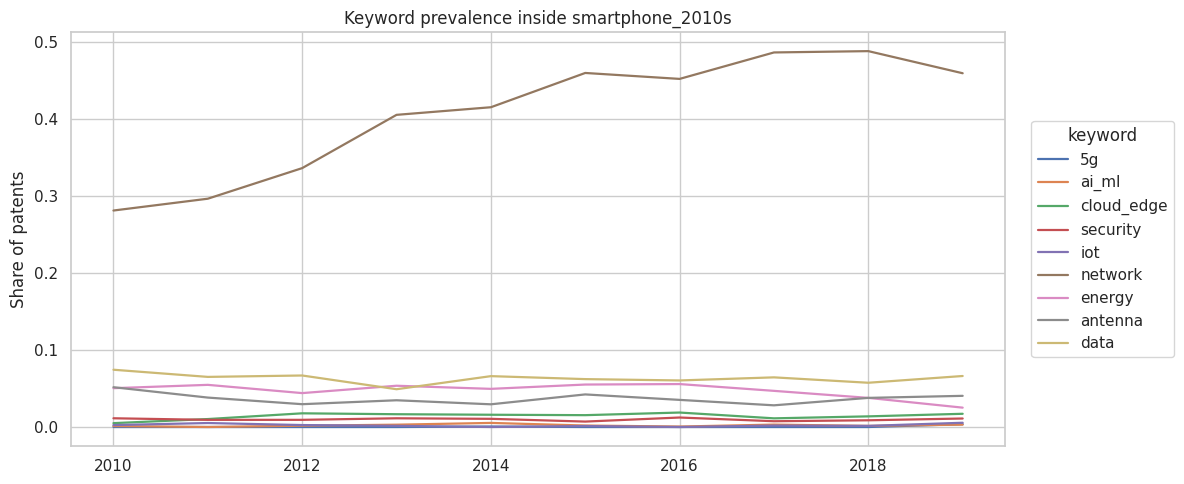

,kw_5g,kw_ai_ml,kw_cloud_edge,kw_security,kw_iot,kw_network,kw_energy,kw_antenna,kw_data
half,,,,,,,,,
2010–2014 (early),0.0002,0.0027,0.0141,0.0104,0.002,0.3599,0.0503,0.0350,0.0633
2015–2019 (late),0.0008,0.0020,0.0154,0.0094,0.002,0.4679,0.0443,0.0367,0.0622


,n,mean_keyword_score,mean_title_words
half,,,
2010–2014 (early),5968,0.538,8.601
2015–2019 (late),7873,0.641,9.097


all 2010–2019 (n=13841): [('network', 2947.0), ('wireless', 1241.0), ('radio', 1079.0), ('control', 960.0), ('node', 917.0), ('data', 859.0), ('mobile', 836.0), ('access', 767.0), ('user', 613.0), ('power', 601.0), ('transmission', 590.0), ('service', 526.0)]
early 2010–2014 (n=5968): [('network', 892.0), ('mobile', 505.0), ('wireless', 422.0), ('control', 383.0), ('data', 374.0), ('radio', 335.0), ('access', 293.0), ('power', 279.0), ('channel', 225.0), ('service', 223.0), ('information', 214.0), ('transmission', 208.0)]
late 2015–2019 (n=7873): [('network', 2055.0), ('wireless', 819.0), ('node', 769.0), ('radio', 744.0), ('control', 577.0), ('data', 485.0), ('access', 474.0), ('user', 407.0), ('transmission', 382.0), ('mobile', 331.0), ('handling', 328.0), ('power', 322.0)]


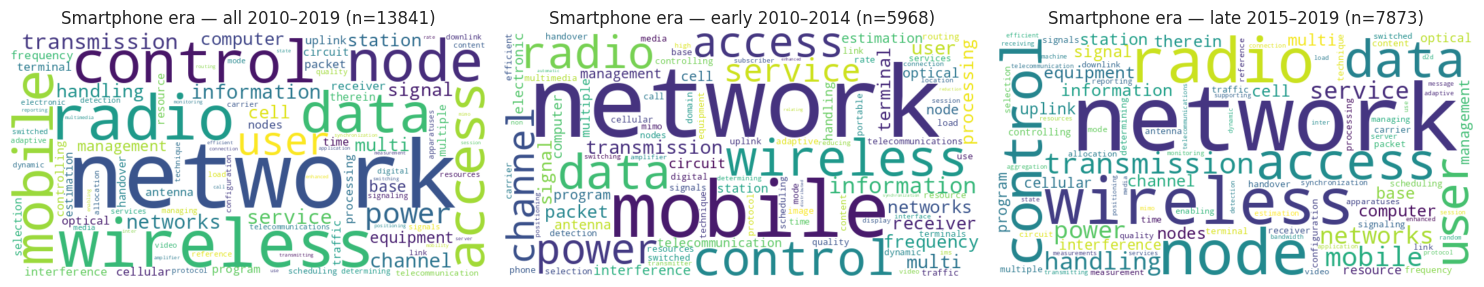

In [10]:
# Smartphone 2010s = calendar years 2010–2019
phone = df[df["tech_era"] == "smartphone_2010s"].copy()
assert phone["year"].min() == 2010 and phone["year"].max() == 2019
assert len(phone) == 13841

phone["half"] = np.where(phone["year"] <= 2014, "2010–2014 (early)", "2015–2019 (late)")

# Volume + type mix
f, ax = plt.subplots(1, 2, figsize=(13, 4.2))
year_counts = phone["year"].value_counts().sort_index()
sns.barplot(x=year_counts.index.astype(str), y=year_counts.values, ax=ax[0], color="#30a2da")
ax[0].set_title("Smartphone era filings by year")
ax[0].set_xlabel("year")
ax[0].set_ylabel("patents")
sns.countplot(data=phone, x="patent_type", ax=ax[1], color="#fc4f30")
ax[1].set_title("Smartphone era — patent_type")
plt.tight_layout()
plt.show()

# Keyword prevalence by year inside the era
annual_phone = phone.groupby("year")[KW_FLAGS].mean()
f, ax = plt.subplots(figsize=(12, 5))
for col in KW_FLAGS:
    ax.plot(annual_phone.index, annual_phone[col], label=col.replace("kw_", ""), lw=1.6)
ax.set_title("Keyword prevalence inside smartphone_2010s")
ax.set_ylabel("Share of patents")
ax.legend(title="keyword", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()

half_kw = phone.groupby("half")[KW_FLAGS].mean().reindex(
    ["2010–2014 (early)", "2015–2019 (late)"]
)
display(half_kw.round(4))
display(
    phone.groupby("half")
    .agg(n=("patent_id", "count"), mean_keyword_score=("keyword_score", "mean"), mean_title_words=("title_len_words", "mean"))
    .round(3)
)

# Wordclouds: full era + early vs late
f, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (label, sub) in zip(
    axes,
    [
        ("all 2010–2019", phone),
        ("early 2010–2014", phone[phone["year"] <= 2014]),
        ("late 2015–2019", phone[phone["year"] >= 2015]),
    ],
):
    freq = titles_to_wordfreq(sub["patent_title"])
    top = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:12]
    print(f"{label} (n={len(sub)}):", top)
    show_wordcloud(freq, f"Smartphone era — {label} (n={len(sub)})", ax=ax)
plt.tight_layout()
plt.show()



**How to Interpret:** <br>
Filing volume peaks mid-decade (around 2014–2016) rather than climbing monotonically. Inside this era, `kw_network` stays dominant; modern tags (`5g`, `ai_ml`, `iot`) barely register until the late half — 5G title language mostly belongs to `modern_2020s`. Early vs late wordclouds show vocabulary drift (e.g. toward wireless / node / network phrasing) that the sparse modern flags understate.


# **9. Forecasting Grain Caution:** <a id="Forecast"></a>



corr(current patent_count, next-quarter target): 0.979
corr(lag1, next target): 0.958


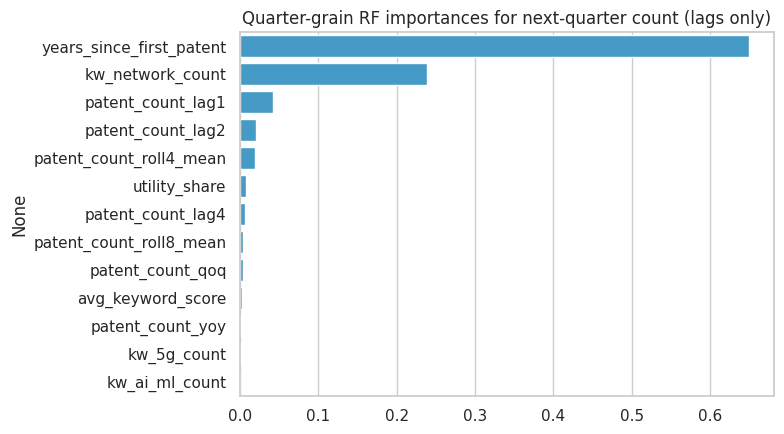

In-sample R^2 (exploratory, not walk-forward): 0.994


In [11]:
q = quarter_df.dropna(subset=["target_patent_count_next_quarter"]).copy()
assert len(q) >= 190
# Naive leakage demo: correlating current count with next target is fine historically,
# but using current patent_count as a "feature" without lag discipline overstates skill.
print("corr(current patent_count, next-quarter target):",
      round(q["patent_count"].corr(q["target_patent_count_next_quarter"]), 3))
print("corr(lag1, next target):",
      round(q["patent_count_lag1"].corr(q["target_patent_count_next_quarter"]), 3)
      if "patent_count_lag1" in q.columns else "n/a")

# Safe-ish feature set for a toy RF at quarter grain
feat_candidates = [
    c for c in [
        "patent_count_lag1", "patent_count_lag2", "patent_count_lag4",
        "patent_count_roll4_mean", "patent_count_roll8_mean",
        "patent_count_qoq", "patent_count_yoy", "years_since_first_patent",
        "utility_share", "avg_keyword_score",
        "kw_5g_count", "kw_ai_ml_count", "kw_network_count",
    ] if c in q.columns
]
# Explicitly exclude leakage columns
leak = {"patent_count", "target_patent_count_current", "target_patent_count_next_quarter"}
assert not (set(feat_candidates) & leak)

X = q[feat_candidates].astype(float)
y = q["target_patent_count_next_quarter"].astype(float)
assert X.notna().all().all(), X.isna().sum().sort_values(ascending=False).head()
rf = RandomForestRegressor(n_estimators=200, random_state=7, max_depth=8, n_jobs=-1)
rf.fit(X, y)
imp = pd.Series(rf.feature_importances_, index=feat_candidates).sort_values(ascending=False)
f, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=imp.values, y=imp.index, ax=ax, color="#30a2da")
ax.set_title("Quarter-grain RF importances for next-quarter count (lags only)")
plt.tight_layout()
plt.show()
print("In-sample R^2 (exploratory, not walk-forward):", round(rf.score(X, y), 3))


**How to Interpret:** <br>
This RF is a grain-correct toy — still in-sample, not a walk-forward forecast. Current-quarter `patent_count` / `target_patent_count_current` were excluded so the model cannot cheat with the present.


# **10. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
Patent-level Ericsson filings with duplicated quarterly aggregates and title-keyword flags over ~50 years.

**Working takeaways:** <br>
- Always dedupe to quarter grain for volume and forecasting.
- `kw_*` flags are **title-regex heuristics**, not CPC technology labels; `keyword_score` is simply how many of the nine fire.
- Title wordclouds by type/decade and the smartphone-2010s slice show vocabulary shifts the binary flags only partly capture.
- Exclude same-quarter targets/counts when framing next-quarter predictors.

**Open follow-ups:** <br>
- Seasonal decomposition / walk-forward validation on `quarter_df`.
- Topic models on `patent_title` beyond the binary keyword flags.

